In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Definitions

In [45]:
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
from scipy.sparse import bmat, diags, block_diag
from scipy.sparse import dok_array, bmat, diags
from scipy.sparse.linalg import expm_multiply

from lattice import Graphene

In [46]:
# print(connections[0])
lattice=Graphene(nmax=40, pbc=None)

na, nb = lattice.n_real_pos

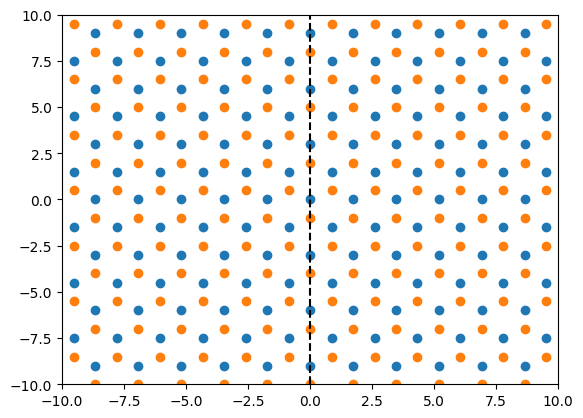

In [41]:
plt.scatter(na[0], na[1])
plt.scatter(nb[0], nb[1])

w = 10
x0 = 0.
plt.xlim(-w, w)
plt.ylim(-w, w)

plt.axvline(x0, color="black", linestyle="dashed")

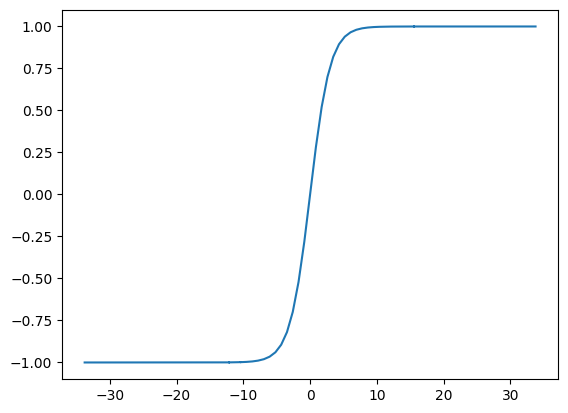

In [48]:
l = 3
x0 = 0

delta = np.tanh((na[0] - x0)/l)
idx = np.argsort(delta)


plt.plot(na[0,idx ], delta[idx])

Text(0, 0.5, 'Eigenvalues')

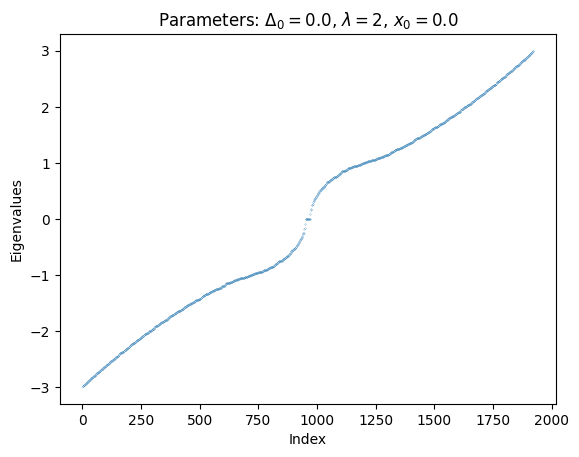

In [ ]:
nmax = 31
delta = 0.5
lambda_0 = 2
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

Text(0, 0.5, 'Eigenvalues')

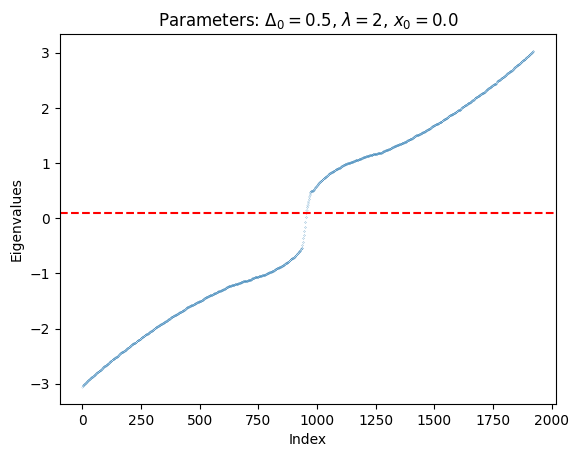

In [212]:
nmax = 31
delta = 0.5
lambda_0 = 2
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.axhline(0.1, color="red", linestyle="dashed")
plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

## Visualizing the gap state

In [125]:
eigvec.shape

(1922, 1922)

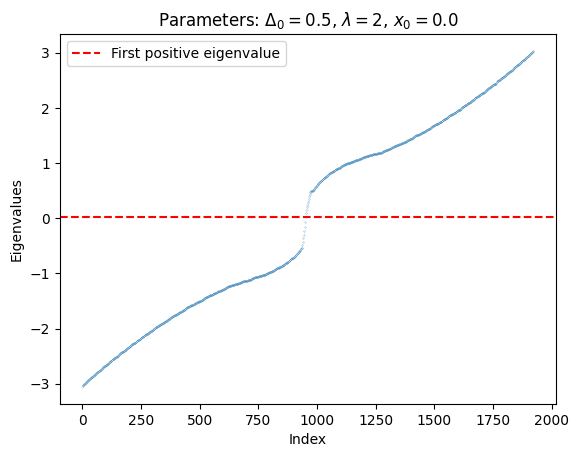

In [126]:
plt.plot(eigval, "o", markersize=0.1)
idx = np.where(eigval > 0)[0][0] # get the first positive

plt.axhline(eigval[idx], color="red", linestyle="dashed", label="First positive eigenvalue")
plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

plt.legend()

In [127]:
idx = np.where(eigval > 0)[0][0] # get the first positive
psi = np.asarray(eigvec[:, idx]).flatten()

psi_a = psi[:lattice.la]
psi_b = psi[lattice.la:]

In [128]:
psi_a.shape

(961,)

In [129]:
def plot_graphene(na, nb, Cna, Cnb, ax, s=5, cmap="hot", vmin=None, vmax=None, logscale=None):
    if logscale:
        Cna = np.log10(Cna)
        Cnb = np.log10(Cnb)

    im = ax.scatter(na[0], na[1] ,c=Cna, s=s, label="A", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.scatter(nb[0], nb[1], c=Cnb, s=s, label="B", cmap=cmap, vmin=vmin, vmax=vmax)

    return im

Text(0.5, 0, 'x')

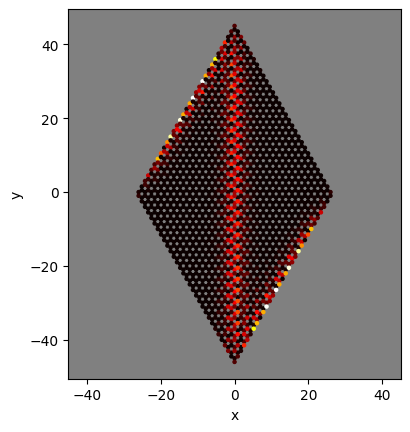

In [130]:
na, nb = lattice.n_real_pos
Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2


fig, ax = plt.subplots()

plot_graphene(na, nb, Cna, Cnb, ax)

ax.set_aspect("equal")
ax.set_xlim(-45, 45)

ax.set_facecolor("gray")

ax.set_ylabel("y")
ax.set_xlabel("x")

In [131]:
eigval[eigval> 0][0]

np.float64(0.014160571823405674)

## Checking emission

In [ ]:
NMAX = 251
delta = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.014
G = 0.1
atom_pos = (0,0)
NUM_POINTS = 25
TF = 200

t = np.linspace(0, TF, NUM_POINTS)
lattice = Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

na, nb = lattice.n_real_pos

H = lattice.hamiltonian
new_dimension = lattice.num_sites() + 1
H.resize((new_dimension, new_dimension))
H = H.astype(np.cdouble)

H[-1, -1] = OMEGA_0
idx = lattice.coord_map["A"][atom_pos]

H[-1, idx] = G
H[idx, -1] = G

psi = np.zeros(new_dimension, dtype=np.cdouble)
psi[-1] = 1.

psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)

psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:lattice.la]
psi_b = psi_latt[:,lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2



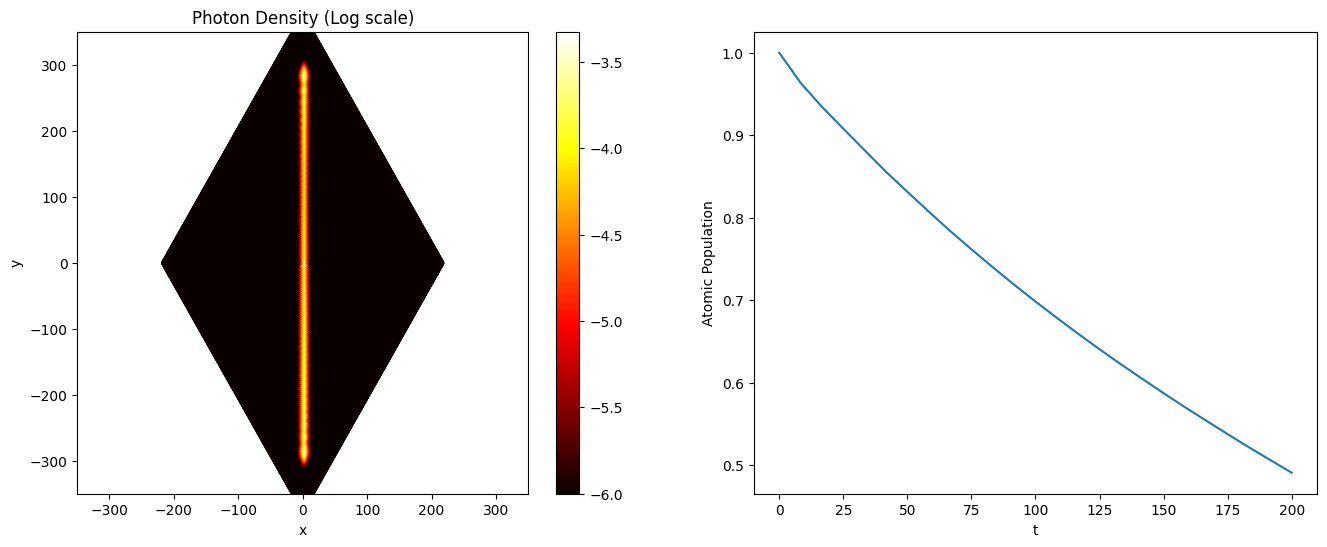

In [146]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
# fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\delta/2 = {DELTA/2}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


### Giant atom

In [149]:
from simulation import System, Eletric_field, Leg

from simulation import add_atom_to_hamiltonian, time_evolution_lattice, time_evolution_atom

In [154]:
NMAX = 251
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.014
G = 0.1
NUM_POINTS = 25
TF = 200

G = 0.1
PHI = np.pi/3
NUM_POINTS = 50

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )

nx = range(- (NMAX // 2), NMAX // 2 + 1)
ny = range(- (NMAX // 2), NMAX // 2 + 1)

Nx, Ny = np.meshgrid(nx, ny)

H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

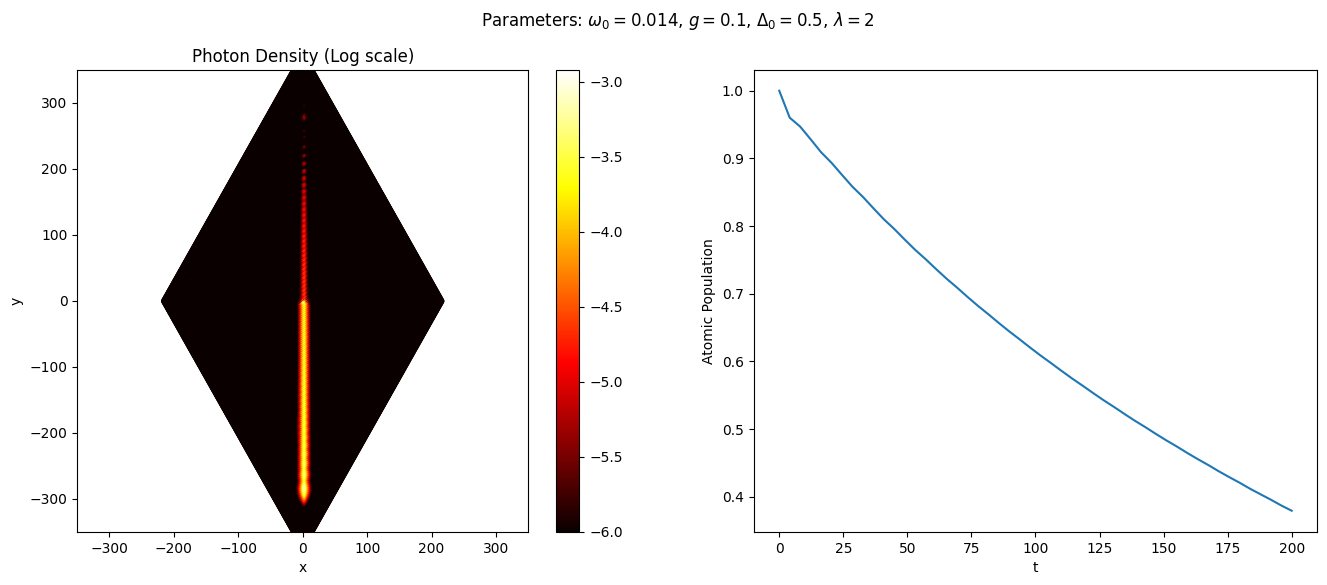

In [155]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

axs[0].set_ylim(-350,350)
axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [200]:
NMAX = 651
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.05
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 400
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

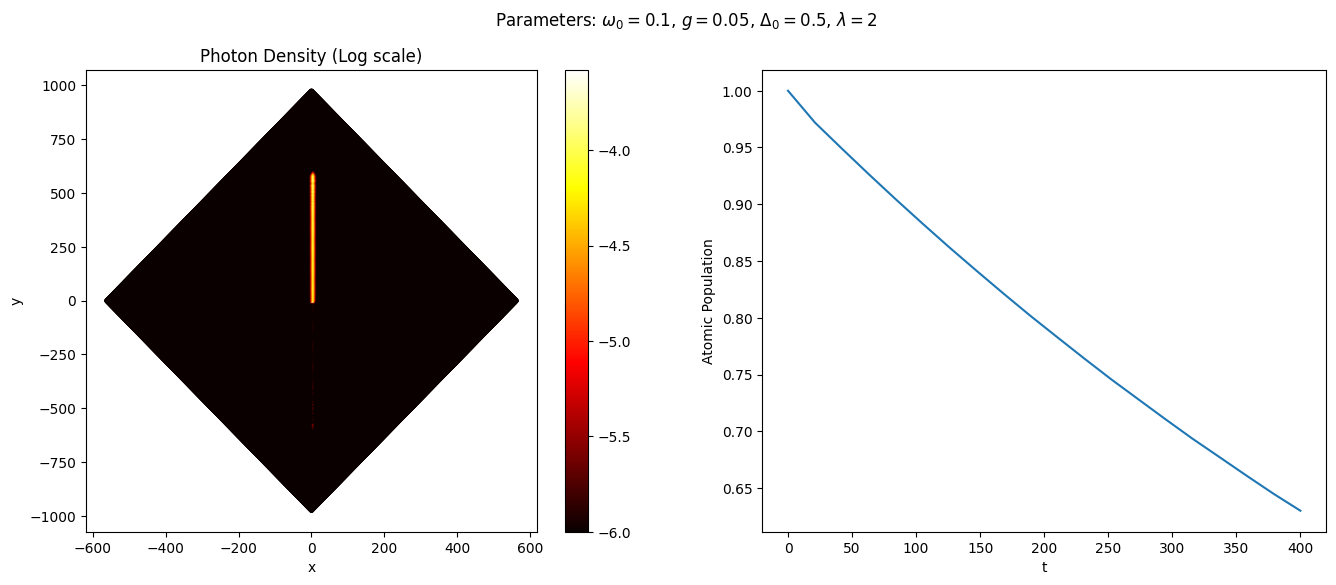

In [201]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


## Emission in a angle

In [215]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 150

THETA = 30 # in degrees
PHI = -np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

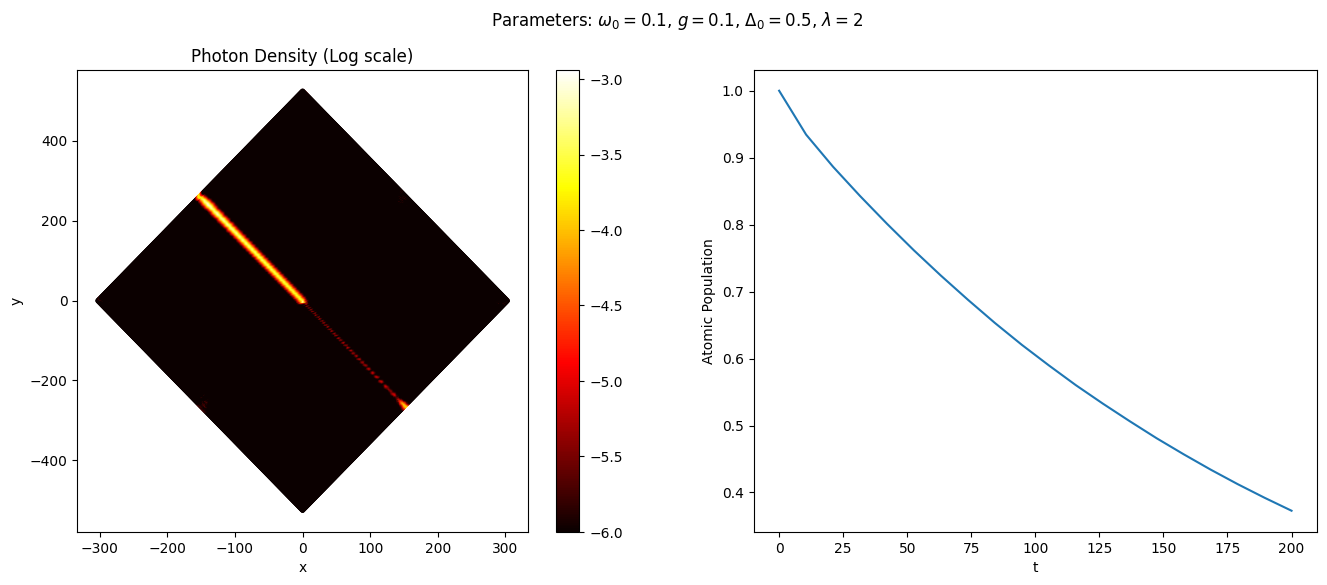

In [ ]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [ ]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 150

THETA = 30 # in degrees
PHI = np.pi/2
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="B", pos=(0,0), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

In [220]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 150

THETA = 45 # in degrees
PHI = -np.pi/3
TF = 120
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_angle=THETA),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

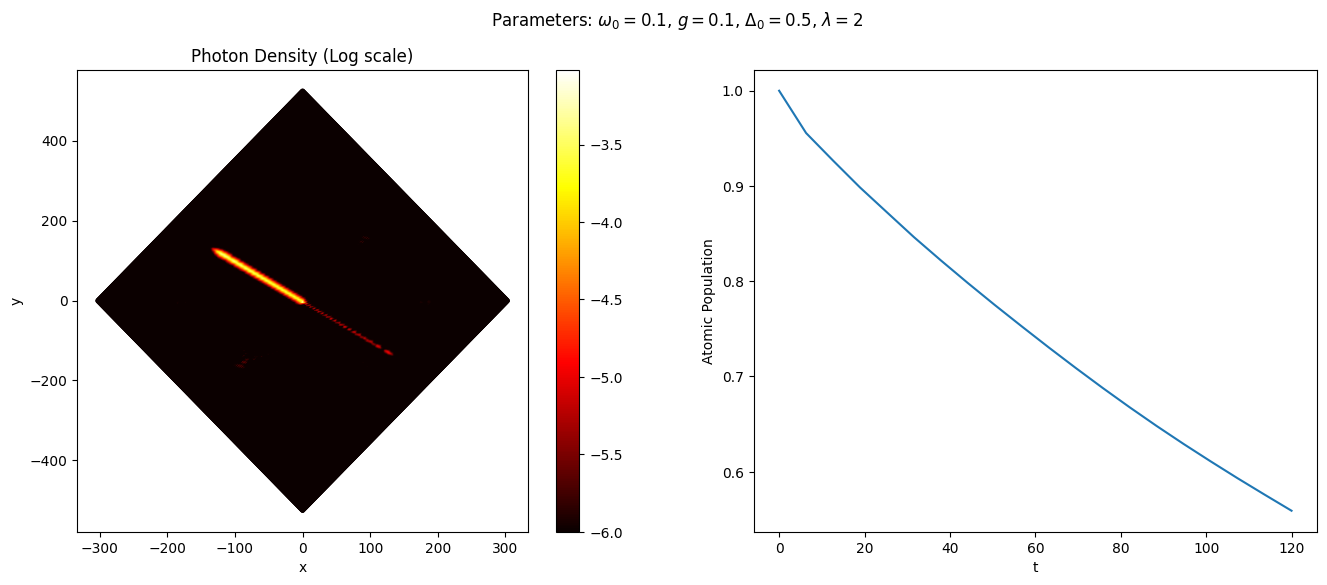

In [221]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -6

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [202]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

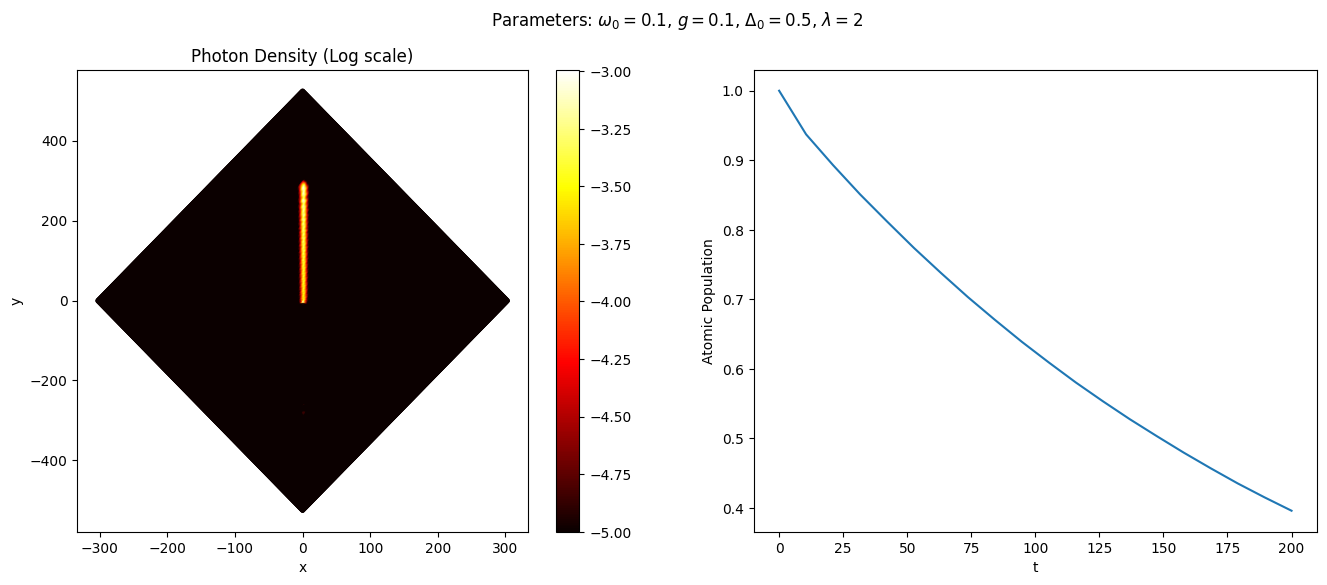

In [204]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [205]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = np.pi/3
TF = 200
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

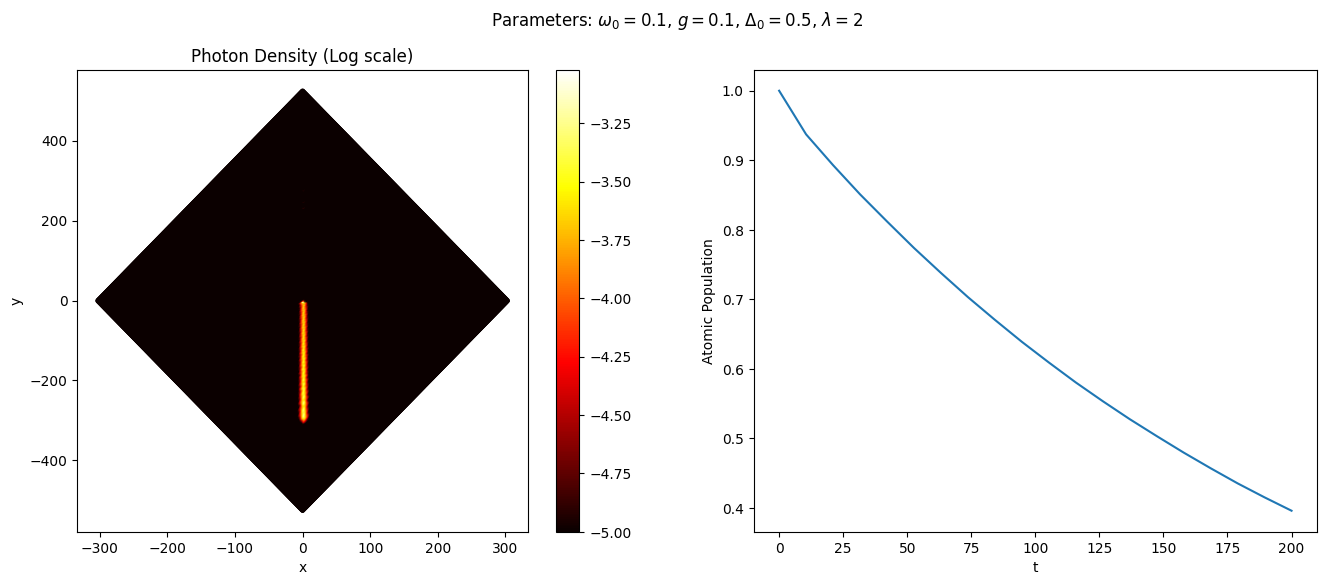

In [206]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [208]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = np.pi/3
TF = 100
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_along="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

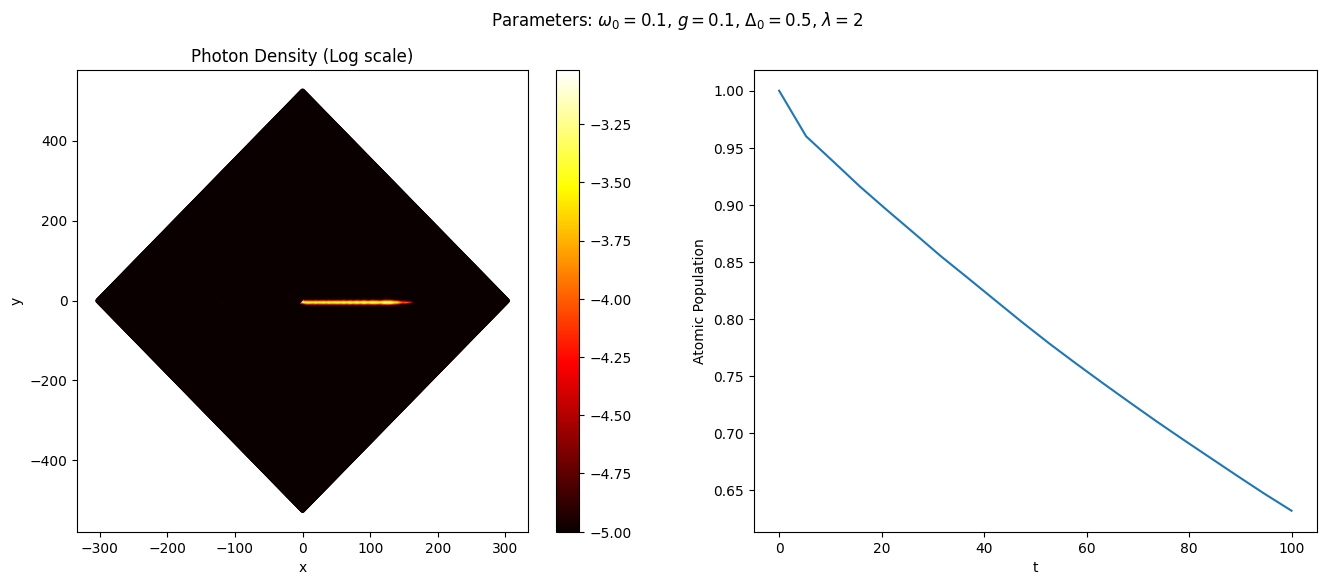

In [209]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


In [210]:
NMAX = 351
DELTA = 0.5
lambda_0 = 2
x0 = 0.
OMEGA_0 = 0.1
G = 0.1
NUM_POINTS = 25
TF = 200

PHI = -np.pi/3
TF = 100
NUM_POINTS = 20

sys=System(
            lattice=Graphene(nmax=NMAX, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y", domain_wall_along="y"),
            omega_0=OMEGA_0,
            g=G,
            legs=[
              Leg(site="A", pos=(0,0)),
              Leg(site="A", pos=(0,1), phase=PHI),
            ]
    )


H = add_atom_to_hamiltonian(sys)
dim = H.shape[0]

t = np.linspace(0, TF, NUM_POINTS)

psi = np.zeros(dim, dtype=np.cdouble)
psi[-1] = 1. # Atom starts on excited state
psi = expm_multiply(-1j * H, psi, start=0, stop=TF, num=NUM_POINTS)


psi_atom = psi[:, -1]
psi_latt = psi[:,:-1]

psi_a = psi_latt[:,:sys.lattice.la]
psi_b = psi_latt[:,sys.lattice.la:]

psi_a = psi_a.reshape((NUM_POINTS, NMAX, NMAX))
psi_b = psi_b.reshape((NUM_POINTS, NMAX, NMAX))

Cna = np.abs(psi_a) ** 2
Cnb = np.abs(psi_b) ** 2
pe = np.abs(psi_atom) ** 2

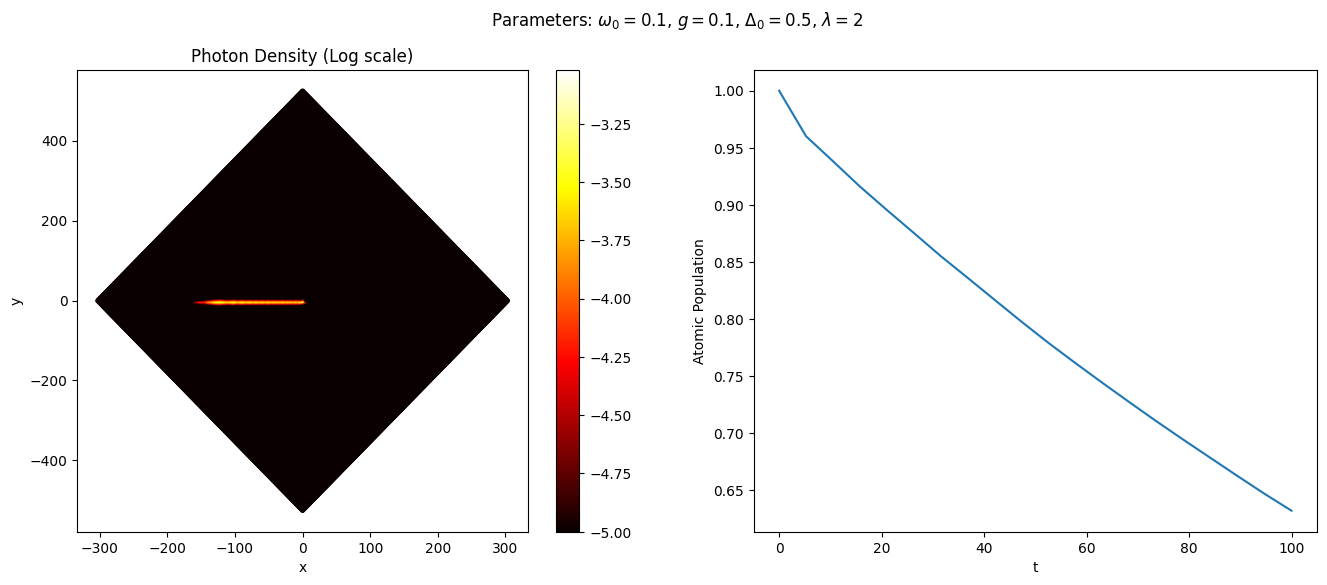

In [211]:
FIG_SIZE = (16, 6)
FILL = False
LOG_SCALE = True
VMAX = None
VMIN = -5

# PARAMS = f"nmax={NMAX}_omega_0={OMEGA_0}_g={G}_delta={DELTA}_epsilon_0={E0}_theta={THETA_DEG}_phi=piO3"

# nx = range(- (NMAX // 2), NMAX // 2 + 1)
# ny = range(- (NMAX // 2), NMAX // 2 + 1)
na, nb = sys.lattice.n_real_pos

fig, axs = plt.subplots(ncols=2, figsize=FIG_SIZE)
im = plot_graphene(na, nb, Cna[-1], Cnb[-1], axs[0], s=5, vmax=VMAX, vmin=VMIN, logscale=LOG_SCALE)

fig.colorbar(im, ax=axs[0])

if FILL:
    axs[0].set_facecolor("black")

axs[0].set_title("Photon Density (Log scale)")
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

a1 = lattice.a1
a2 = lattice.a2

# draw_basis_vectors(axs[0], [a1, a2])
# annotate_electric_field_text(axs[0], sys)


axs[1].plot(t, pe)

axs[1].set_xlabel("t")
axs[1].set_ylabel("Atomic Population")
fig.suptitle(f"Parameters: $\\omega_0={OMEGA_0}$, $g={G}$, $\\Delta_0 = {DELTA}$, $\\lambda = {lambda_0}$")

# axs[0].set_ylim(-350,350)
# axs[0].set_xlim(-350, 350)

plt.show()
# fig.savefig(f"emitted_field_and_population_{PARAMS}.pdf")


Text(0, 0.5, 'Eigenvalues')

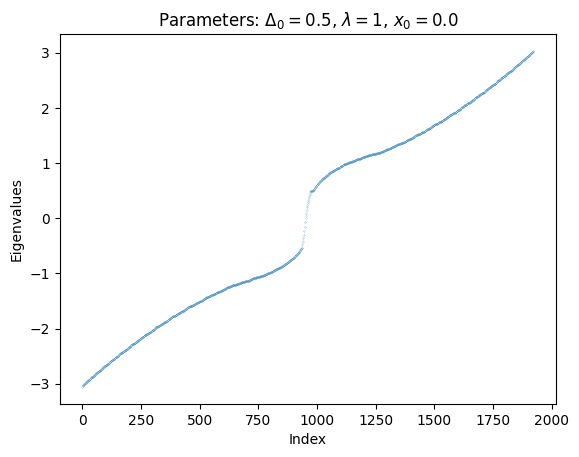

In [57]:
nmax = 31
delta = 0.5
lambda_0 = 1
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

Text(0, 0.5, 'Eigenvalues')

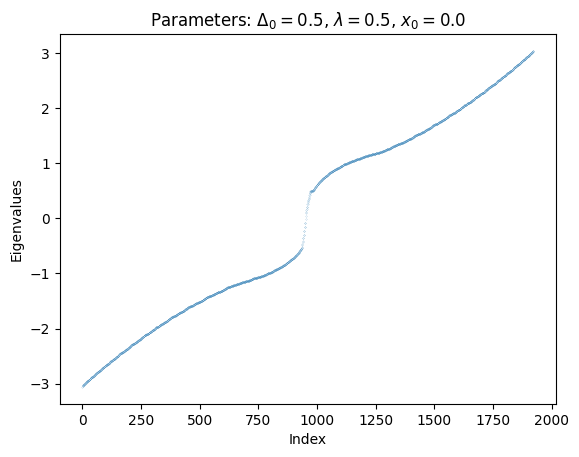

In [58]:
nmax = 31
delta = 0.5
lambda_0 = 0.5
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

Text(0, 0.5, 'Eigenvalues')

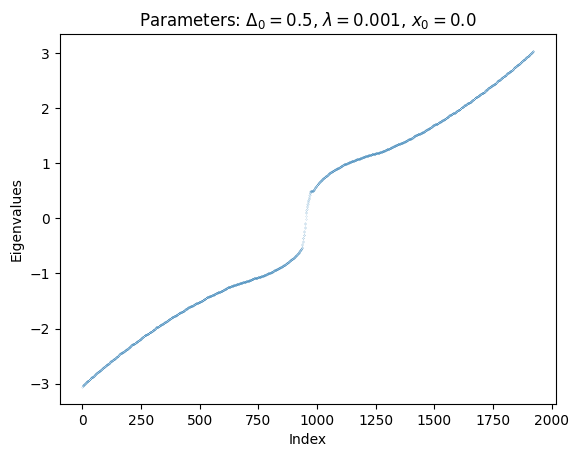

In [60]:
nmax = 31
delta = 0.5
lambda_0 = 0.001
x0 = 0.

lattice = Graphene(nmax=nmax, x0=x0, delta_0=delta, lambda_0=lambda_0, pbc="y")

eigval, eigvec = np.linalg.eigh(lattice.hamiltonian.todense())

plt.plot(eigval, "o", markersize=0.1)

plt.title(f"Parameters: $\\Delta_0 = {delta}$, $\\lambda = {lambda_0}$, $x_0 = {x0}$")
plt.xlabel("Index")
plt.ylabel("Eigenvalues")

In [ ]:
a = np.array([1,2,3])
b = np.array

np.vstack()

In [5]:
def generate_rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

## Testing the boundary conditions

In [6]:
nmax = 4
N = nmax ** 2
connections = {
    n: [
        n + nmax if n + nmax < N else None, 
        n + nmax - 1 if n + nmax < N else None, 
        n + 1 if n + 1 < N else None, 
        n - 1 if n - 1 >=0 else None, 
        n - nmax + 1 if n - nmax >= 0 else None, 
        n - nmax if n - nmax >= 0 else None
        ] for n in range(N)
}

In [7]:
def check_connections(m, N, connections):
    c = np.arange(N)[connections]
    site_row = m // nmax
    same_rows = (c // nmax) == site_row
    next_rows = np.abs((c // nmax) - site_row) == 1
    distance_row = np.abs(c - m) == 1

    return c[(same_rows & distance_row) | next_rows]


In [8]:
nmax = 4
N = nmax ** 2
connections = {
    n: check_connections(
        m=n,
        N=N,
        connections=np.array([
                n + nmax, 
                n + nmax - 1, 
                n + 1, 
                n - 1 , 
                n - nmax + 1 , 
                n - nmax 
                ]) % N
            ) for n in range(N)
}

In [9]:
M = np.zeros((N,N))
for key, value in connections.items():
    M[key, value] = 1

In [10]:
# M

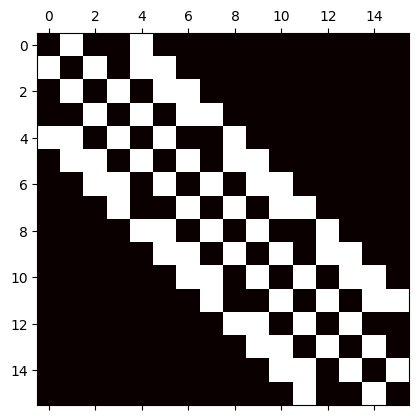

In [11]:
im = plt.matshow(M, cmap="hot")
# plt.colorbar(im)

In [12]:
check_connections(m=5, N=N, connections=connections[5])

array([9, 8, 6, 4, 2, 1])

In [13]:
nmax = 4
N = nmax ** 2
connections_pbc = {
    n: [
        (n + nmax) % N, 
        (n + nmax - 1) % N, 
        (n + 1) % N, 
        (n - 1) % N, 
        (n - nmax + 1) % N, 
        (n - nmax) % N
        ] for n in range(N)
}
M_PBC = np.zeros((N, N))

for key, value in connections_pbc.items():
    M_PBC[key, value] = 1

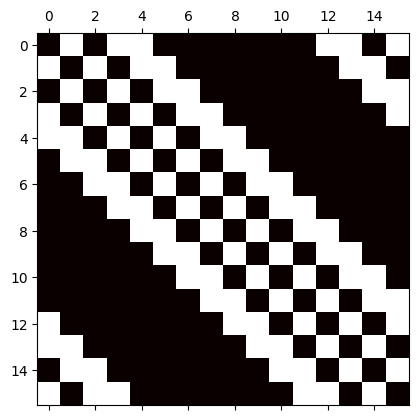

In [14]:
plt.matshow(M_PBC, cmap="hot")

In [15]:
m = 5
c = np.arange(N)[connections[m]]

site_row = m // nmax
same_rows = (c // nmax) == site_row
next_rows = np.abs((c // nmax) - site_row) == 1
distance_row = np.abs(c - m) == 1

c[(same_rows & distance_row) | next_rows]

array([9, 8, 6, 4, 2, 1])

## PBC y

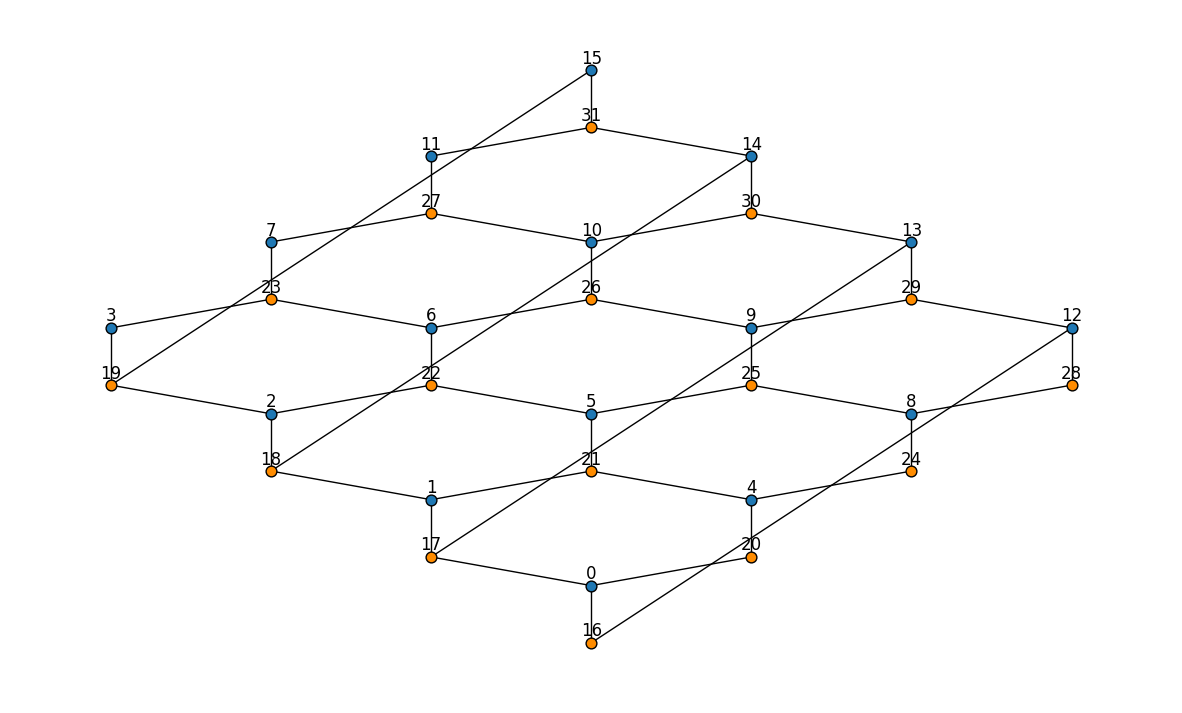

In [112]:
# print(connections[0])
lattice=Graphene(nmax=4, J_prime=0, pbc="y")
fig, _ = lattice.plot(True)

In [17]:
G = lattice.graph

In [18]:
G.edges(11)

EdgeDataView([(11, 27), (11, 31)])

## PBC x

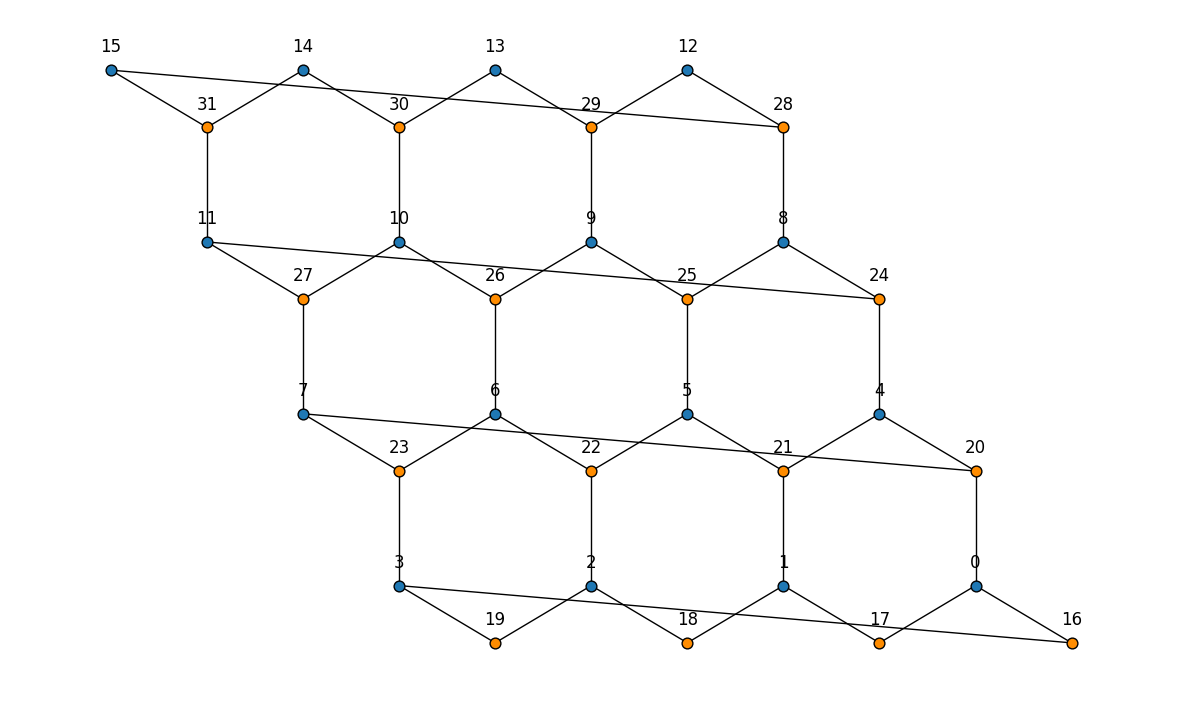

In [19]:
lattice=Graphene(nmax=4, pbc="x")
fig, _ = lattice.plot(True, theta_rot=np.pi/3)

array([[[1, 2],
        [3, 4]]])

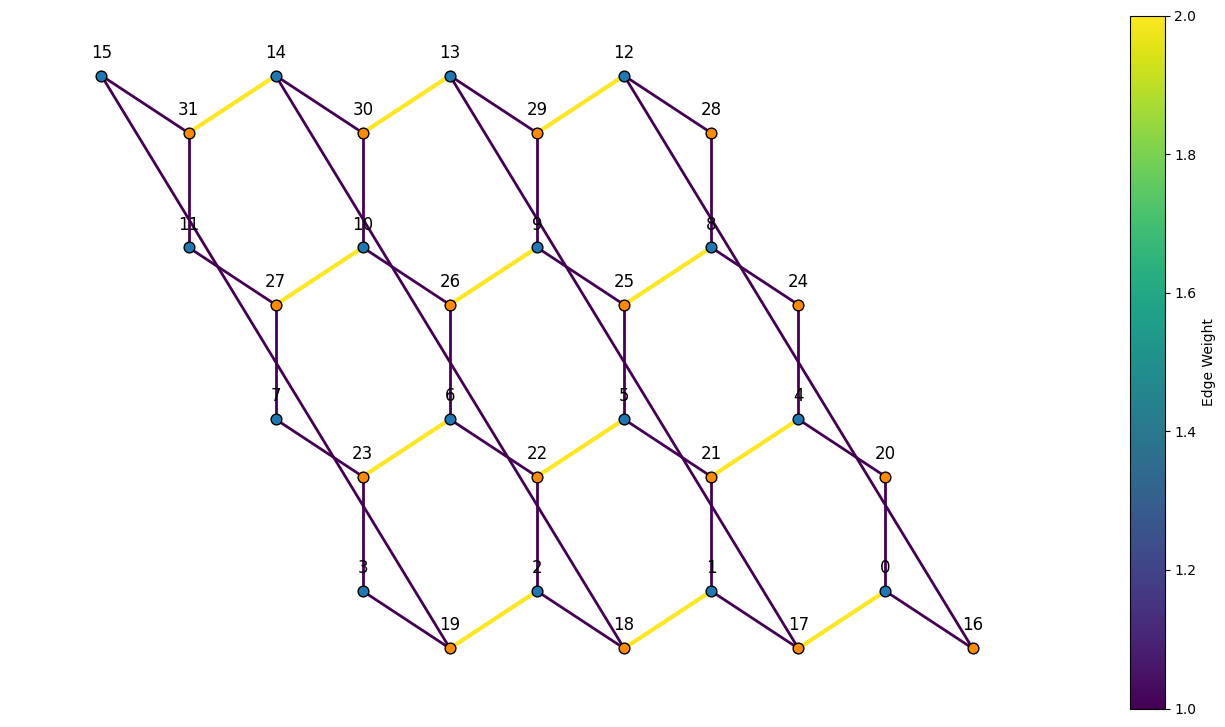

In [20]:
# print(connections[0])
lattice=Graphene(nmax=4, pbc="y", anisotropy_J=2)
fig, _ = lattice.plot(True, theta_rot=np.pi/3, color_by_weight=True)

# fig.savefig("graphene.svg")

In [31]:
lattice=Graphene(nmax=4, J_prime=-1, pbc=None)


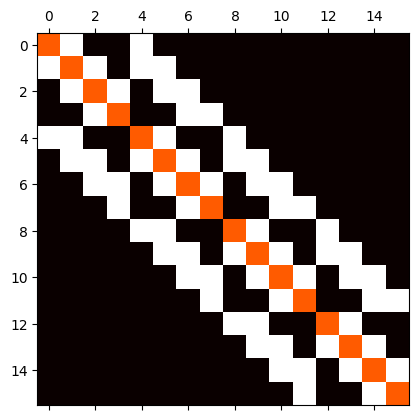

In [ ]:
# Non PBC
nmax = 4

def build_diag(ki):
    k = np.full(nmax ** 2 - ki, 1.)
    
    if ki == 1:
      k[nmax-1::nmax] = 0
      return k
    
    if ki == nmax - 1:
       k[::nmax] = 0
       return k
    
    if ki == (2 * nmax - 1):
       k[:] = 0
       k[::nmax] = 1.
       return k

    return k


energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

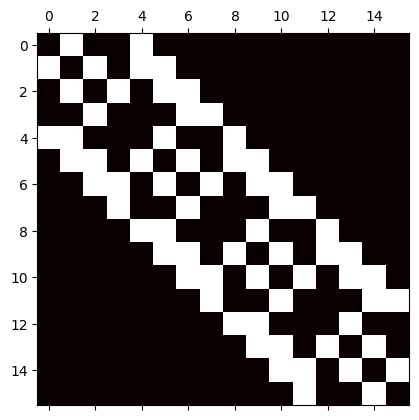

In [281]:
# Non PBC

nmax = 4


k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k3[::nmax] = 0 # k = 3 


k4 = np.full(nmax ** 2 - nmax, 1.)

M = diags([k1, k3, k4] * 2, offsets=[1, nmax - 1, nmax, -1, -(nmax-1), - nmax])

plt.matshow(M.todense(), cmap="hot")

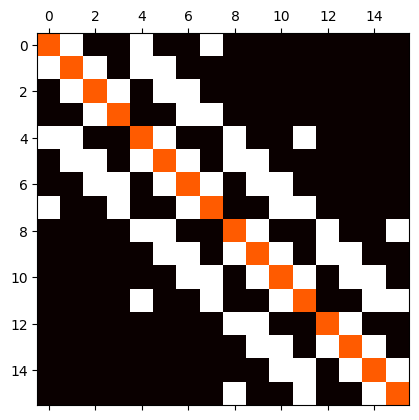

In [ ]:
# PBC X

energy = np.full(nmax ** 2, 0.5)

ks = [1, nmax - 1, nmax, 2 * nmax - 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

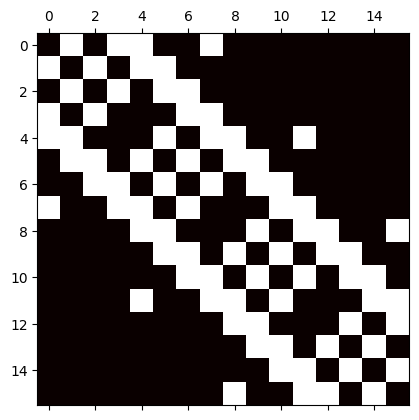

In [ ]:
# PBC X

nmax = 4

k1 = np.full(nmax ** 2 - 1, 1.)
k1[nmax-1::nmax] = 0 # k = 1 


k3 = np.full(nmax ** 2 - (nmax - 1), 1.)
k4 = np.full(nmax ** 2 - nmax, 1.)

k7 = np.zeros(nmax ** 2 - (2 * nmax - 1))
k7[::nmax] = 1


M = diags([k1, k3, k4, k7] * 2, offsets=[1, (nmax - 1), nmax, (2 * nmax - 1), -1, -(nmax - 1), -nmax, -(2 * nmax - 1)])

plt.matshow(M.todense(), cmap="hot")

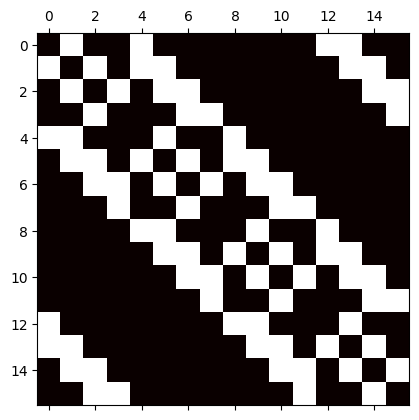

In [59]:
# PBC Y

energy = np.full(nmax ** 2, 0.)

ks = [1, nmax - 1, nmax, nmax * (nmax - 1), nmax * (nmax - 1) + 1]
k = [build_diag(ki) for ki in ks]
offsets = ks + [-ki for ki in ks]

M = diags([energy] + k * 2, offsets=[0] + offsets)

plt.matshow(M.todense(), cmap="hot")

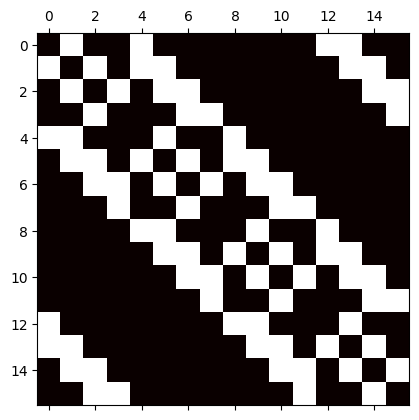

In [ ]:

PBC = "y"
nmax = 4

ks = [1, nmax - 1, nmax]
kextra = []

if PBC == "y":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1]

if PBC == "x":
    kextra = [2 * nmax - 1]

if PBC == "xy":
    kextra = [nmax * (nmax - 1), nmax * (nmax - 1) + 1, 2 * nmax - 1]

ks += kextra
ksm = [-k for k in ks]

K = [np.full(nmax ** 2 - k, 1.)for k in ks]

K[0][nmax-1::nmax] = 0
K[1][::nmax] = 0
if PBC == ("x" or "xy"):
    K[1] = 1.
    K[-1] = np.zeros(nmax ** 2 - (2 * nmax - 1))
    K[-1][::nmax] = 1.
    
K = K * 2
ks = ks + ksm

M = diags(K, offsets=ks)

plt.matshow(M.todense(), cmap="hot")

In [291]:
nmax ** 2 - nmax

12

In [ ]:
k11 = np.full()